# Week 2 — NumPy, Pandas, and Data Visualization

**Course context:** This is where "programming" turns into "data work." NumPy gives you fast array math (the engine under every ML library). Pandas gives you a spreadsheet-like structure for real datasets. Matplotlib/Seaborn let you actually *look* at the data before modeling it — skipping this step is one of the most common causes of bad models later.

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


## Day 1 — NumPy Basics: Arrays, Indexing, Element-wise Math

**What it covers:** Creating NumPy arrays, indexing/slicing, reshaping, and element-wise arithmetic.

**Why it matters for AI work:** NumPy arrays are the actual data structure every ML/DL library uses under the hood (Pandas columns, PyTorch/TensorFlow tensors are all "NumPy but faster/GPU-capable"). Vectorized math (`a + b` operating on whole arrays at once) is why NumPy code runs 10-100x faster than the equivalent Python `for` loop.

**When to use what:**
- Plain Python list → small, one-off collections, mixed types
- NumPy array → any numeric data you'll do math on, especially in bulk (this is basically always, once you're doing ML)

**Pitfalls:**
- `a + b` on two NumPy arrays is **element-wise**, not matrix multiplication. For matrix multiplication use `a @ b` or `np.dot(a, b)`. Mixing these up gives wrong numbers, not an error — the dangerous kind of bug.
- `.reshape(2, 3)` requires the total element count to match exactly (2×3=6). Reshaping a 5-element array into `(2,3)` raises a `ValueError`.
- Array slicing (`arr[1:4]`) returns a **view**, not a copy — modifying the slice modifies the original array. Use `.copy()` if you need an independent copy.


In [1]:
import numpy as np

arr = np.array([10, 20, 30, 40, 50, 60])
print(arr[2])       # index access
print(arr[-1])      # last element

print(arr[1:4])     # slice: elements at index 1,2,3
print(arr[3:])      # from index 3 to the end

reshaped = arr.reshape(2, 3)   # must have 2*3 = 6 elements, matches original size
print(reshaped)

30
60
[20 30 40]
[40 50 60]
[[10 20 30]
 [40 50 60]]


In [2]:
a = np.arange(1, 6)     # [1 2 3 4 5]
b = np.arange(6, 11)    # [6 7 8 9 10]

print(a)
print(b)

print("Add: ", a + b)     # element-wise
print("Sub: ", a - b)
print("Mult: ", a * b)    # element-wise multiply, NOT matrix multiply
print("Div: ", a / b)

[1 2 3 4 5]
[ 6  7  8  9 10]
Add:  [ 7  9 11 13 15]
Sub:  [-5 -5 -5 -5 -5]
Mult:  [ 6 14 24 36 50]
Div:  [0.16666667 0.28571429 0.375      0.44444444 0.5       ]


In [3]:
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("Original Matrix:\n", matrix)

transpose = matrix.T                      # flips rows <-> columns
print("Transpose:\n", transpose)

another_matrix = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])
print("Addition:\n", matrix + another_matrix)
print("Element-wise Multiplication:\n", matrix * another_matrix)
print("True Matrix Multiplication (@):\n", matrix @ another_matrix)

Original Matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Transpose:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
Addition:
 [[10 10 10]
 [10 10 10]
 [10 10 10]]
Element-wise Multiplication:
 [[ 9 16 21]
 [24 25 24]
 [21 16  9]]
True Matrix Multiplication (@):
 [[ 30  24  18]
 [ 84  69  54]
 [138 114  90]]


## Day 2 — Broadcasting, Random Arrays, and Filtering

**What it covers:** Broadcasting (combining arrays of different shapes), generating random data, and boolean masking (filtering arrays by condition).

**Why it matters for AI work:** Broadcasting is how you add a bias vector to every row of a weight matrix in a neural network without writing a loop. Boolean masking is exactly how you filter datasets (`data[data > threshold]`) and how Pandas filtering works internally.

**When to use what:**
- Broadcasting — combining a big array with a smaller one (e.g. adding a single row/vector to every row of a matrix) without manually looping or resizing
- `np.random.seed(n)` — set this whenever you need **reproducible** randomness (debugging, sharing results, comparing experiments fairly)
- Boolean masking (`arr[arr > x]`) — filtering without a for-loop

**Pitfalls:**
- Broadcasting rules are strict: shapes must be equal, or one of them must be size 1 in the mismatched dimension. `(3,3) + (1,3)` works; `(3,3) + (2,3)` doesn't and raises a `ValueError`.
- `dataset[dataset > 25] = 0` **mutates the array in place** — if you needed the original values later, you've lost them. Copy first if you need both versions.
- Forgetting `np.random.seed(...)` means every run gives different random numbers — fine for real training, bad for debugging ("why did my output change?").


In [4]:
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
vector = np.array([1, 0, -1])

# Broadcasting: the (3,) vector is applied to every row of the (3,3) matrix
result_add = matrix + vector
print("Add (broadcast):\n", result_add)

result_mul = matrix * 2   # scalar broadcasts to every element
print("Scalar Multiplication:\n", result_mul)

Add (broadcast):
 [[2 2 2]
 [5 5 5]
 [8 8 8]]
Scalar Multiplication:
 [[ 2  4  6]
 [ 8 10 12]
 [14 16 18]]


In [5]:
np.random.seed(42)   # reproducible randomness

random_array = np.random.rand(3, 3)               # uniform floats in [0, 1)
print("Random Array:\n", random_array)

random_integers = np.random.randint(0, 10, size=(2, 3))   # random ints in [0, 10)
print("Random Integers:\n", random_integers)

Random Array:
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]]
Random Integers:
 [[7 2 5]
 [4 1 7]]


In [6]:
# Filtering with boolean masks + summary statistics
np.random.seed(1)
dataset = np.random.randint(1, 51, size=(5, 5))
print("Original:\n", dataset)

dataset_filtered = dataset.copy()          # copy first - the next line mutates in place
dataset_filtered[dataset_filtered > 25] = 0
print("Modified Dataset (values > 25 -> 0):\n", dataset_filtered)

print("Sum: ", np.sum(dataset))
print("Mean: ", np.mean(dataset))
print("Standard Deviation: ", np.std(dataset))

Original:
 [[38 44 13  9 10]
 [12  6 16  1 17]
 [ 2 13  8 46  7]
 [26 21 38 19 21]
 [12 43 29 30 15]]
Modified Dataset (values > 25 -> 0):
 [[ 0  0 13  9 10]
 [12  6 16  1 17]
 [ 2 13  8  0  7]
 [ 0 21  0 19 21]
 [12  0  0  0 15]]
Sum:  496
Mean:  19.84
Standard Deviation:  13.174763754997658


## Day 3 — Pandas Basics: Series, DataFrame, Viewing and Selecting Data

**What it covers:** `pd.Series`, `pd.DataFrame`, viewing data (`head`, `tail`, `info`, `describe`), and selecting rows/columns (`loc`, `iloc`, boolean filtering).

**Why it matters for AI work:** A DataFrame is how you'll interact with essentially every real dataset. `.info()` and `.describe()` are the first two commands you run on *any* new dataset — they tell you column types, missing values, and basic statistics before you do anything else.

**When to use what:**
- `.loc[]` — select by **label** (row/column names)
- `.iloc[]` — select by **integer position** (like list indexing)
- Boolean filtering (`df[df["Age"] > 25]`) — select rows matching a condition (most common in practice)

**Pitfalls:**
- `.loc[0]` selects the row **labeled** `0` — if the index has been changed/reset, this is not necessarily the *first* row. `.iloc[0]` always means "the first row," regardless of labels.
- `df.info()` prints directly and returns `None` — `print(df.info())` will print the info AND then print `None` afterward. Just call `df.info()` on its own line.
- Real-world CSV loading — `pd.read_csv(url_or_path)` — often needs `encoding=`, `sep=`, or `na_values=` arguments for messy files. The default assumptions (`utf-8`, comma-separated) don't always hold.


In [7]:
import pandas as pd
import numpy as np

s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s)

a    10
b    20
c    30
dtype: int64


In [8]:
data = {"Name": ["Alice", "Bob", "Charlie", "Diana"], "Age": [25, 30, 22, 28]}
df = pd.DataFrame(data)

# Viewing data
print(df.head())
print(df.tail(3))

df.info()               # call on its own line - it prints directly and returns None
print(df.describe())    # summary statistics for numeric columns

print(df[["Name", "Age"]])          # select specific columns
print(df[df["Age"] > 25])           # boolean filter: rows where Age > 25

print(df.iloc[0])       # first row, by POSITION
print(df.iloc[:, 0])    # first column, by POSITION

print(df.loc[0])        # row labeled 0
print(df.loc[:, "Name"])   # column labeled "Name"

      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   22
3    Diana   28
      Name  Age
1      Bob   30
2  Charlie   22
3    Diana   28
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    4 non-null      str  
 1   Age     4 non-null      int64
dtypes: int64(1), str(1)
memory usage: 196.0 bytes
         Age
count   4.00
mean   26.25
std     3.50
min    22.00
25%    24.25
50%    26.50
75%    28.50
max    30.00
      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   22
3    Diana   28
    Name  Age
1    Bob   30
3  Diana   28
Name    Alice
Age        25
Name: 0, dtype: object
0      Alice
1        Bob
2    Charlie
3      Diana
Name: Name, dtype: str
Name    Alice
Age        25
Name: 0, dtype: object
0      Alice
1        Bob
2    Charlie
3      Diana
Name: Name, dtype: str


In [9]:
# Real dataset: load, select columns, filter rows
df_iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

selected_columns = df_iris[["species", "sepal_length"]]
print("Selected Columns:\n", selected_columns.head())

filtered_rows = df_iris[(df_iris["sepal_length"] > 5.0) & (df_iris["species"] == "setosa")]
print("Filtered Rows:\n", filtered_rows)

Selected Columns:
   species  sepal_length
0  setosa           5.1
1  setosa           4.9
2  setosa           4.7
3  setosa           4.6
4  setosa           5.0
Filtered Rows:
     sepal_length  sepal_width  petal_length  petal_width species
0            5.1          3.5           1.4          0.2  setosa
5            5.4          3.9           1.7          0.4  setosa
10           5.4          3.7           1.5          0.2  setosa
14           5.8          4.0           1.2          0.2  setosa
15           5.7          4.4           1.5          0.4  setosa
16           5.4          3.9           1.3          0.4  setosa
17           5.1          3.5           1.4          0.3  setosa
18           5.7          3.8           1.7          0.3  setosa
19           5.1          3.8           1.5          0.3  setosa
20           5.4          3.4           1.7          0.2  setosa
21           5.1          3.7           1.5          0.4  setosa
23           5.1          3.3           1

## Day 4 — Cleaning and Combining Data: Missing Values, Renaming, Merge/Concat

**What it covers:** Handling missing values (`fillna`, `interpolate`), renaming columns, and combining DataFrames (`merge`, `concat`, `join`).

**Why it matters for AI work:** Real datasets are never clean. Missing values, mismatched column names across sources, and needing to combine multiple tables (e.g. a customers table + an orders table) is most of what "data preprocessing" actually is — often more work than the modeling itself.

**When to use what:**
- `.fillna(value)` — fill missing values with a fixed value or a statistic (mean/median/mode)
- `.interpolate()` — fill missing values by estimating from neighboring values (works well for ordered/time-series data)
- `pd.merge(df1, df2, on="key")` — combine two tables using a shared key column, like a SQL join
- `pd.concat([df1, df2], axis=0)` — stack rows (same columns, more data); `axis=1` — stack columns side by side (same rows, more features)

**Pitfalls:**
- `.fillna(df["Age"].mean())` computes the mean **including** any rows you might want to exclude (e.g. outliers). Always sanity-check the fill value makes sense before applying it.
- `merge(how="inner")` (the default) **drops rows that don't match** in both tables. If you need to keep all rows from one side, use `how="left"` or `how="right"` explicitly — silently losing rows is a common data bug.
- Column name collisions during merge get suffixed automatically (`_x`, `_y`) — check `df.columns` after merging to make sure you're referencing the right one.


In [10]:
import pandas as pd
import numpy as np

data = {
    "Name": ["Alice", "Bob", np.nan, "David"],
    "Age": [25, np.nan, 30, 35],
    "Score": [85, 90, np.nan, 88],
}
df = pd.DataFrame(data)
print("Original Dataset:\n", df)

df["Age"] = df["Age"].fillna(df["Age"].mean())   # fill with the column mean
df["Score"] = df["Score"].interpolate()           # fill by interpolating neighbors

df = df.rename(columns={"Name": "Student_Name", "Score": "Exam_Score"})
print("Cleaned Dataset:\n", df)

Original Dataset:
     Name   Age  Score
0  Alice  25.0   85.0
1    Bob   NaN   90.0
2    NaN  30.0    NaN
3  David  35.0   88.0
Cleaned Dataset:
   Student_Name   Age  Exam_Score
0        Alice  25.0        85.0
1          Bob  30.0        90.0
2          NaN  30.0        89.0
3        David  35.0        88.0


In [11]:
df1 = pd.DataFrame({
    "ID": [1, 2, 3],
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
})

df2 = pd.DataFrame({
    "ID": [1, 2, 3],
    "Score": [85, 90, 88]
})

print("Dataset 1:\n", df1)
print("Dataset 2:\n", df2)

merged = pd.merge(df1, df2, how="inner", on="ID")
print("Merged Dataset:\n", merged)

merged["Score_Percentage"] = (merged["Score"] / 200) * 100
print("Transformed Dataset:\n", merged)

Dataset 1:
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
2   3  Charlie   35
Dataset 2:
    ID  Score
0   1     85
1   2     90
2   3     88
Merged Dataset:
    ID     Name  Age  Score
0   1    Alice   25     85
1   2      Bob   30     90
2   3  Charlie   35     88
Transformed Dataset:
    ID     Name  Age  Score  Score_Percentage
0   1    Alice   25     85              42.5
1   2      Bob   30     90              45.0
2   3  Charlie   35     88              44.0


In [12]:
# concat vs merge vs join - quick comparison on the same data
stacked_rows = pd.concat([df1, df1], axis=0)          # stack rows (duplicates ID here, just for demo)
print("Concat axis=0 (stack rows):\n", stacked_rows)

side_by_side = pd.concat([df1, df2.drop(columns="ID")], axis=1)   # stack columns
print("Concat axis=1 (stack columns):\n", side_by_side)

left_merged = pd.merge(df1, df2, how="left", on="ID")   # keeps ALL rows from df1
print("Left merge:\n", left_merged)

Concat axis=0 (stack rows):
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
2   3  Charlie   35
0   1    Alice   25
1   2      Bob   30
2   3  Charlie   35
Concat axis=1 (stack columns):
    ID     Name  Age  Score
0   1    Alice   25     85
1   2      Bob   30     90
2   3  Charlie   35     88
Left merge:
    ID     Name  Age  Score
0   1    Alice   25     85
1   2      Bob   30     90
2   3  Charlie   35     88


## Day 5 — Grouping and Aggregation

**What it covers:** `.groupby()`, `.agg()`, and pivot tables — splitting data into groups and computing statistics per group.

**Why it matters for AI work:** This is how you go from raw rows to insight — "average purchase by customer segment," "accuracy by class," "loss by epoch." Every EDA (exploratory data analysis) report leans heavily on groupby.

**When to use what:**
- `.groupby("col").mean()` — one statistic per group, simple case
- `.groupby("col").agg({...})` — multiple statistics, possibly different ones per column
- `.pivot_table()` — reshape into a spreadsheet-style summary table (rows = one variable, columns = another)

**Pitfalls:**
- `.groupby()` alone returns a `GroupBy` object, not a DataFrame — you need to chain an aggregation (`.mean()`, `.agg()`, etc.) or iterate over it to see results.
- Grouping by a high-cardinality column (e.g. one with 10,000 unique values) creates 10,000 tiny groups — usually not useful. Group by categorical variables with a manageable number of distinct values.
- Custom aggregation functions (like `range_func` below) run **once per group** — if the function is slow, this can be a real performance cost on large datasets.


In [13]:
import pandas as pd

data = {
    "Class": ["A", "B", "A", "B", "C", "C"],
    "Score": [85, 90, 88, 72, 95, 80],
    "Age": [15, 16, 15, 17, 16, 15],
}
df = pd.DataFrame(data)
print("Original Dataset:\n", df)

grouped_mean = df.groupby("Class").mean(numeric_only=True)
print("Mean per Class:\n", grouped_mean)

stats = df.groupby("Class").agg(
    {"Score": ["mean", "max", "min"], "Age": ["mean", "max", "min"]}
)
print("Multiple Stats per Class:\n", stats)

Original Dataset:
   Class  Score  Age
0     A     85   15
1     B     90   16
2     A     88   15
3     B     72   17
4     C     95   16
5     C     80   15
Mean per Class:
        Score   Age
Class             
A       86.5  15.0
B       81.0  16.5
C       87.5  15.5
Multiple Stats per Class:
       Score           Age        
       mean max min  mean max min
Class                            
A      86.5  88  85  15.0  15  15
B      81.0  90  72  16.5  17  16
C      87.5  95  80  15.5  16  15


In [14]:
# Iterating over groups directly
for name, group in df.groupby("Class"):
    print(f"--- Class {name} ---")
    print(group)

# Pivot table: same idea, spreadsheet-style layout
pivot = df.pivot_table(values="Score", index="Class", aggfunc="mean")
print("Pivot Table:\n", pivot)

# Custom aggregation function
def range_func(x):
    return x.max() - x.min()

print("Score range per Class:\n", df.groupby("Class")["Score"].agg(range_func))

--- Class A ---
  Class  Score  Age
0     A     85   15
2     A     88   15
--- Class B ---
  Class  Score  Age
1     B     90   16
3     B     72   17
--- Class C ---
  Class  Score  Age
4     C     95   16
5     C     80   15
Pivot Table:
        Score
Class       
A       86.5
B       81.0
C       87.5
Score range per Class:
 Class
A     3
B    18
C    15
Name: Score, dtype: int64


## Day 6 — Data Visualization: Matplotlib and Seaborn

**What it covers:** Line plots, bar charts, scatter plots, histograms, heatmaps, and pairplots.

**Why it matters for AI work:** Before you train any model, plotting your data catches problems a table of numbers hides — outliers, skewed distributions, correlated features (which can break linear models), and class imbalance. "Look at your data first" prevents a lot of wasted modeling time.

**When to use what:**
- Line plot — trend over an ordered variable (time, epoch number)
- Bar chart — comparing a statistic across categories
- Scatter plot — relationship between two numeric variables
- Histogram — the distribution/shape of one numeric variable
- Heatmap (of a correlation matrix) — spotting which features move together (relevant for feature selection later)
- Pairplot — scatter plots of every pair of numeric columns at once — a fast first look at a whole dataset

**Pitfalls:**
- `sns.heatmap(df.corr())` on a DataFrame that still has non-numeric columns will fail (or silently drop them, depending on version) — drop or encode non-numeric columns first.
- `sns.pairplot()` gets slow and visually unreadable past ~6-8 numeric columns — subset the columns you actually care about first.
- Forgetting `plt.show()` in a plain `.py` script means the plot never displays. In a notebook it usually renders automatically, but it's good practice to keep `plt.show()` anyway for portability.


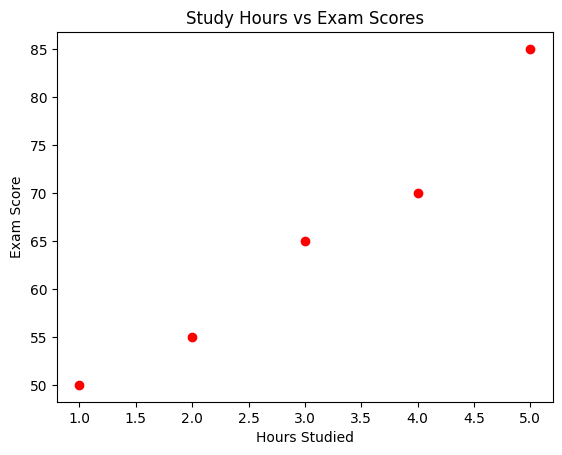

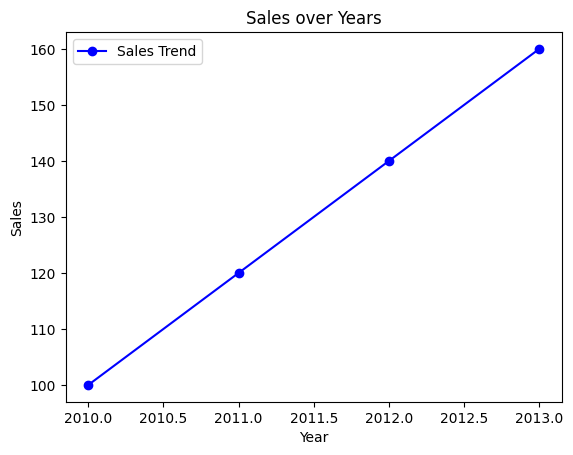

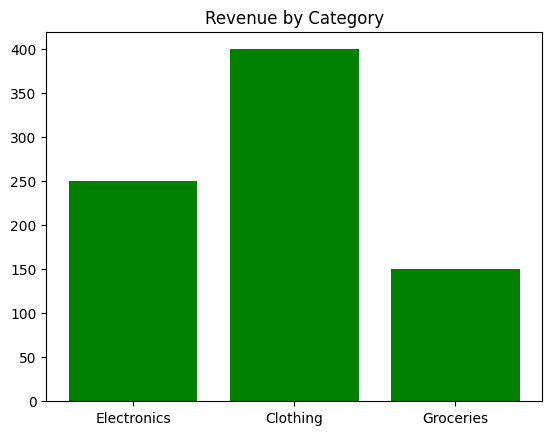

In [15]:
import matplotlib.pyplot as plt

# Scatter plot
hours_studied = [1, 2, 3, 4, 5]
exam_scores = [50, 55, 65, 70, 85]
plt.scatter(hours_studied, exam_scores, color="red")
plt.title("Study Hours vs Exam Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

# Line plot
years = [2010, 2011, 2012, 2013]
sales = [100, 120, 140, 160]
plt.plot(years, sales, label="Sales Trend", color="blue", marker="o")
plt.title("Sales over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Bar chart
categories = ["Electronics", "Clothing", "Groceries"]
revenue = [250, 400, 150]
plt.bar(categories, revenue, color="green")
plt.title("Revenue by Category")
plt.show()

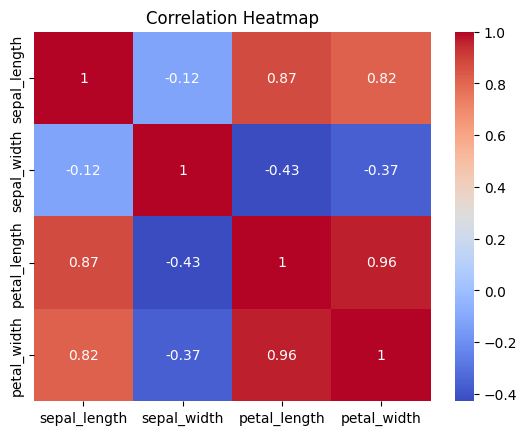

In [16]:
import seaborn as sns
import numpy as np

# Heatmap of a correlation matrix (numeric columns only)
df_iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
numeric_df = df_iris.drop(columns=["species"])   # drop non-numeric column before corr()

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

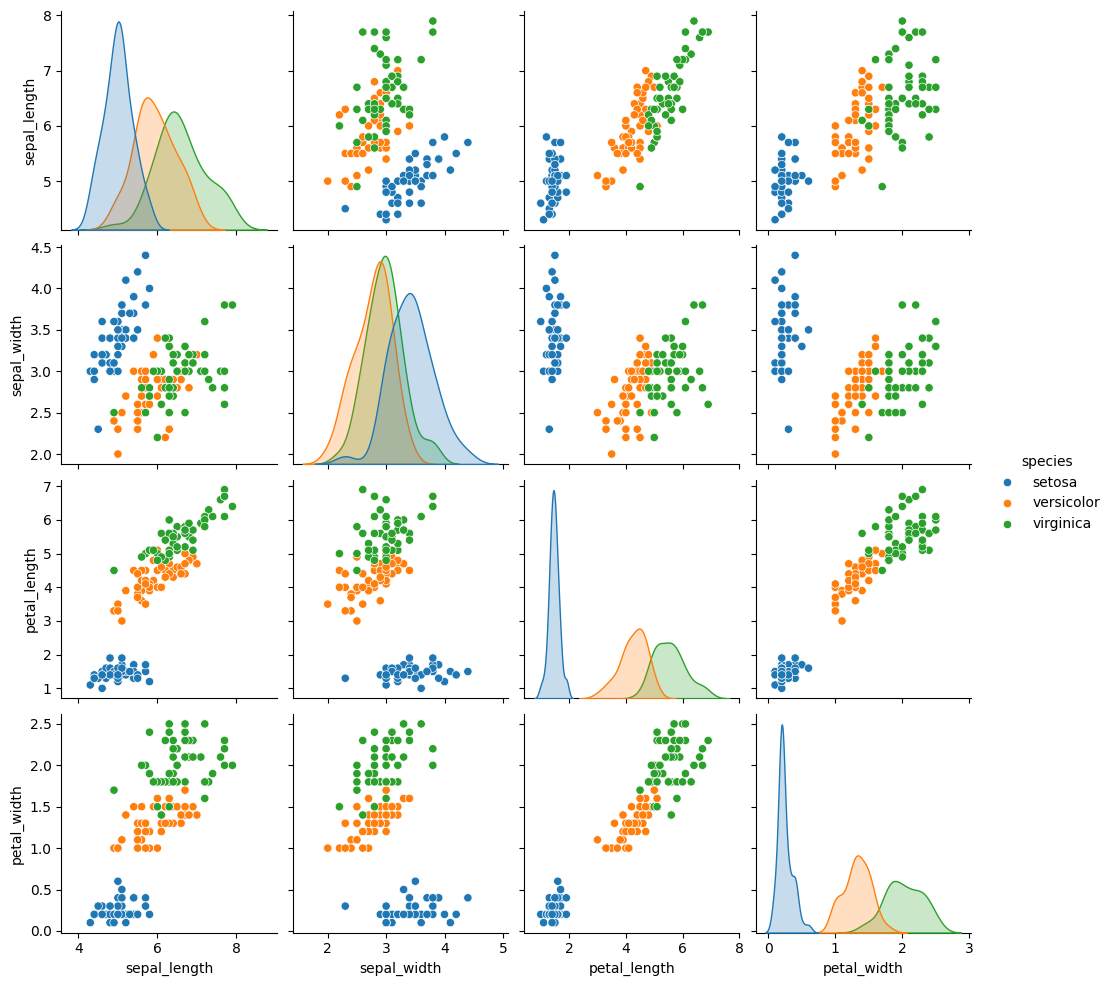

In [17]:
# Pairplot: every pair of numeric columns, colored by species
sns.pairplot(df_iris, hue="species")
plt.show()

## Day 7 — Mini Project: Exploratory Data Analysis on the Titanic Dataset

**What it covers:** A full, realistic EDA pass: load → inspect → clean missing values → deduplicate → filter → visualize. This is the standard first step of nearly every ML project.

**Why it matters for AI work:** This exact sequence — inspect, clean, visualize, THEN model — is the actual day-to-day workflow of an ML/data engineer. Skipping straight to model training without this step is one of the most common beginner mistakes; it produces models that quietly learn from bad data.

**Pitfalls:**
- Filling `Age` with the **median** (not mean) is deliberate here — age distributions are often skewed (a few very old passengers), and the median is more robust to outliers than the mean.
- `df.drop_duplicates()` only removes rows that are **exact** duplicates across all columns — near-duplicates (e.g. same passenger, slightly different data entry) won't be caught.
- Plotting `Age` vs `Fare` directly on the raw Titanic data will show a heavily skewed `Fare` distribution (a few very expensive first-class tickets) — worth noticing before feeding this feature into a model unscaled.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Step 1: Inspect
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.5

In [19]:
# Step 2: Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())          # median: robust to outliers
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])   # mode: most common category

# Step 3: Remove exact duplicate rows
df = df.drop_duplicates()

# Step 4: Filter - first class passengers only
first_class = df[df["Pclass"] == 1]
print("First Class Passengers:\n", first_class.head())

First Class Passengers:
     PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
11           12         1       1   
23           24         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   
23                       Sloper, Mr. William Thompson    male  28.0      0   

    Parch    Ticket     Fare Cabin Embarked  
1       0  PC 17599  71.2833   C85        C  
3       0    113803  53.1000  C123        S  
6       0     17463  51.8625   E46        S  
11      0    113783  26.5500  C103        S  
23      0    113788  35.5000    A6        S  


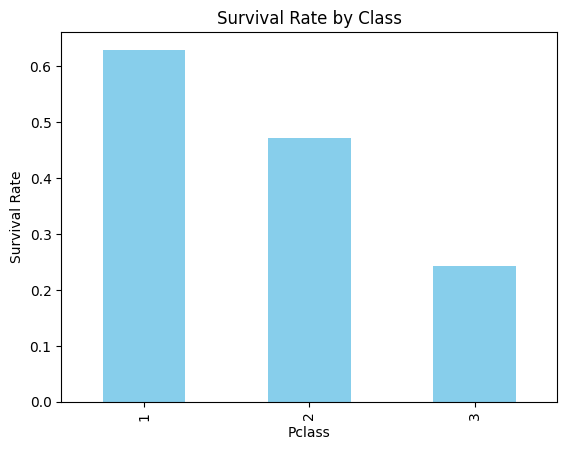

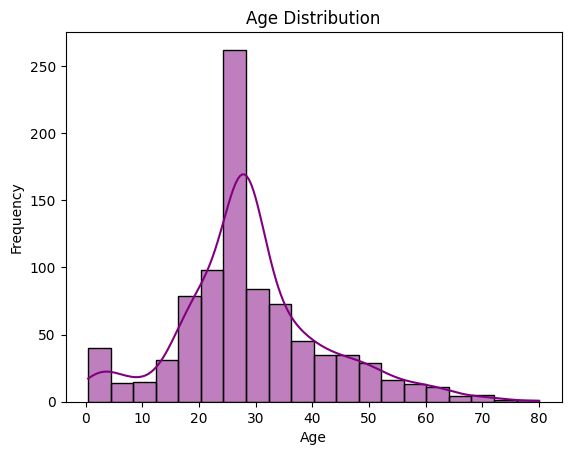

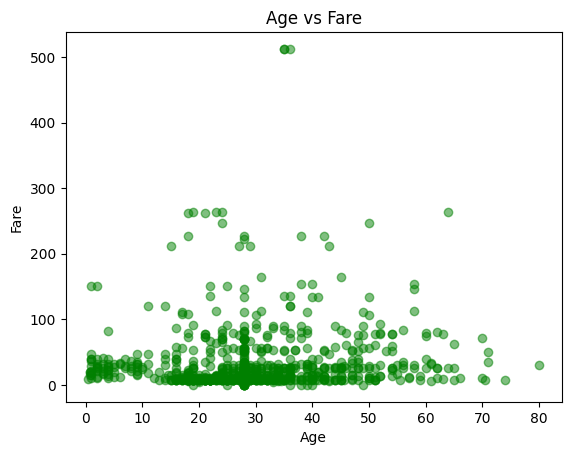

In [20]:
# Step 5: Visualize
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar", color="skyblue")
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.show()

sns.histplot(df["Age"], kde=True, bins=20, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df["Age"], df["Fare"], alpha=0.5, color="green")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## Week 2 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | NumPy arrays, indexing | Every ML library's underlying data structure |
| 2 | Broadcasting, random, masking | Neural net math, reproducible experiments, filtering |
| 3 | Pandas Series/DataFrame basics | Loading and inspecting any dataset |
| 4 | Cleaning, merging | Real-world messy multi-source data |
| 5 | Groupby/aggregation | EDA, per-class/per-segment metrics |
| 6 | Visualization | Catching data problems before modeling |
| 7 | Full EDA mini-project | The actual first step of every real ML project |

**Before moving to Week 3:** you should be able to load a CSV, get a feel for it with `.info()`/`.describe()`, filter rows by condition, and produce at least a histogram and scatter plot without looking things up. Week 3 assumes comfortable Pandas + NumPy, then builds the math (linear algebra, calculus, probability) that ML algorithms are made of.
